# Exploratory Data Analysis (EDA)

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [18]:
# Load the Barcelona noise ML dataset
dataset = pd.read_csv("data/bcn_noise_class_ml_dataset.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (11711, 22)
['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


## Reduce the number of columns

In [19]:
print(dataset.columns.tolist())

['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


<Axes: >

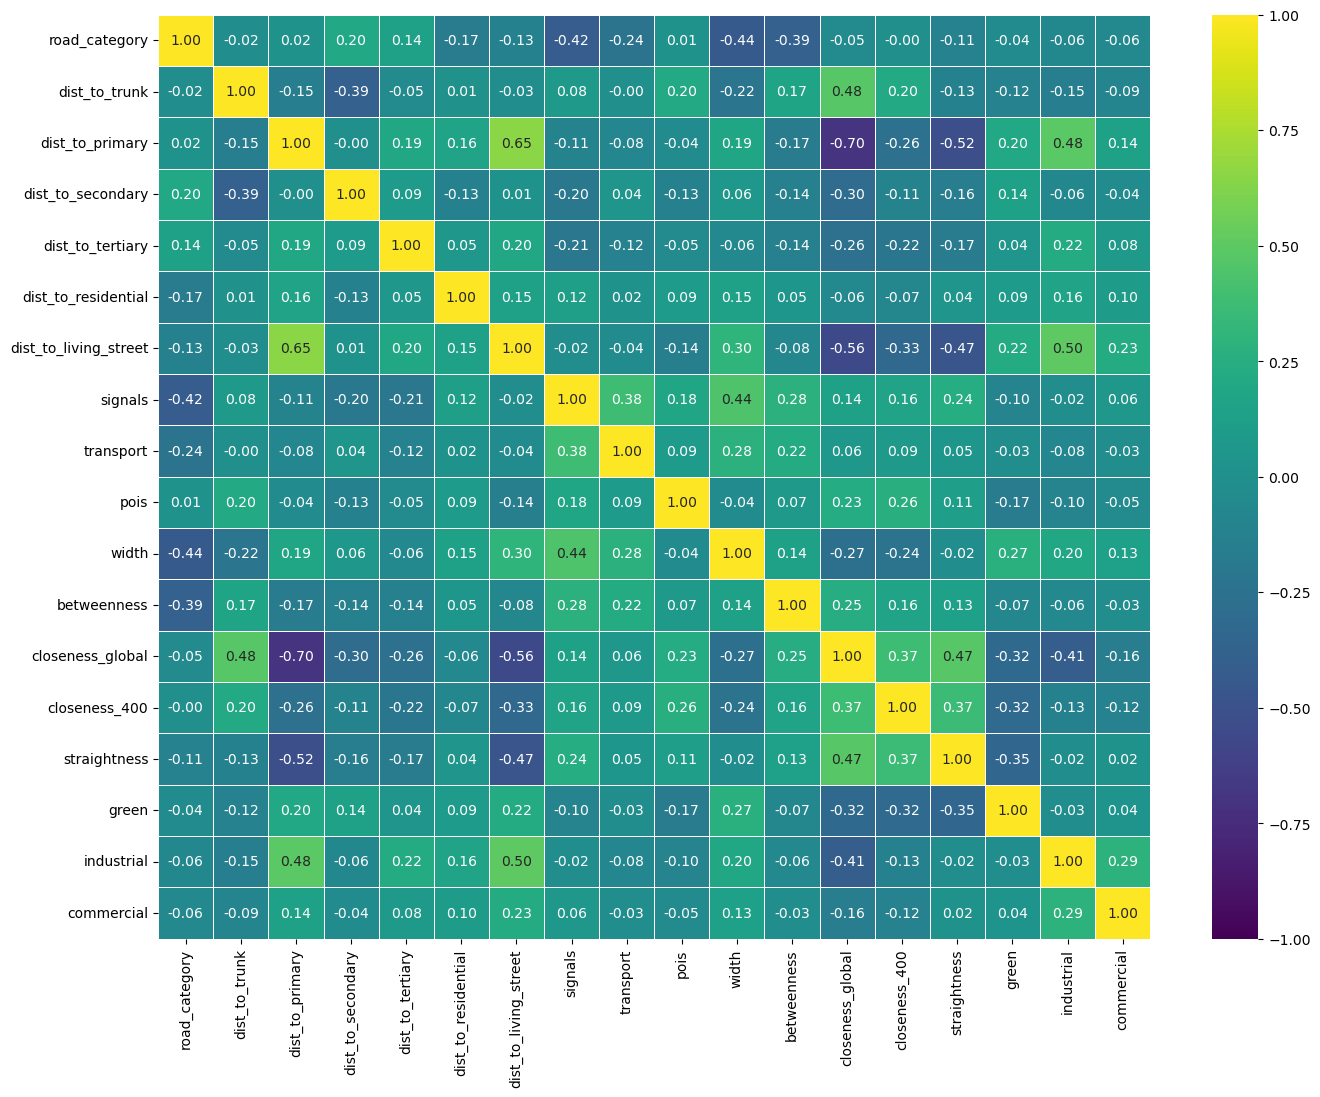

In [20]:
dataset_features = dataset.drop(columns=['road_id', 'noise_day', 'noise_evening', 'noise_night']) #dropping y and non-relevant columns
plt.figure(figsize=(16, 12))  # width, height in inches
sns.heatmap(dataset_features.corr(), center=0, linewidths=0.5,
                 cmap="viridis", vmin=-1, vmax=1, annot=True, fmt=".2f")

## Calculate Spearman correlation

Pearson measures linear relationships
-> very sensitive to outliers and nonlinear patterns

Spearman measures rank-order relationships
-> works well with nonlinear relationships and is more robust to outliers 

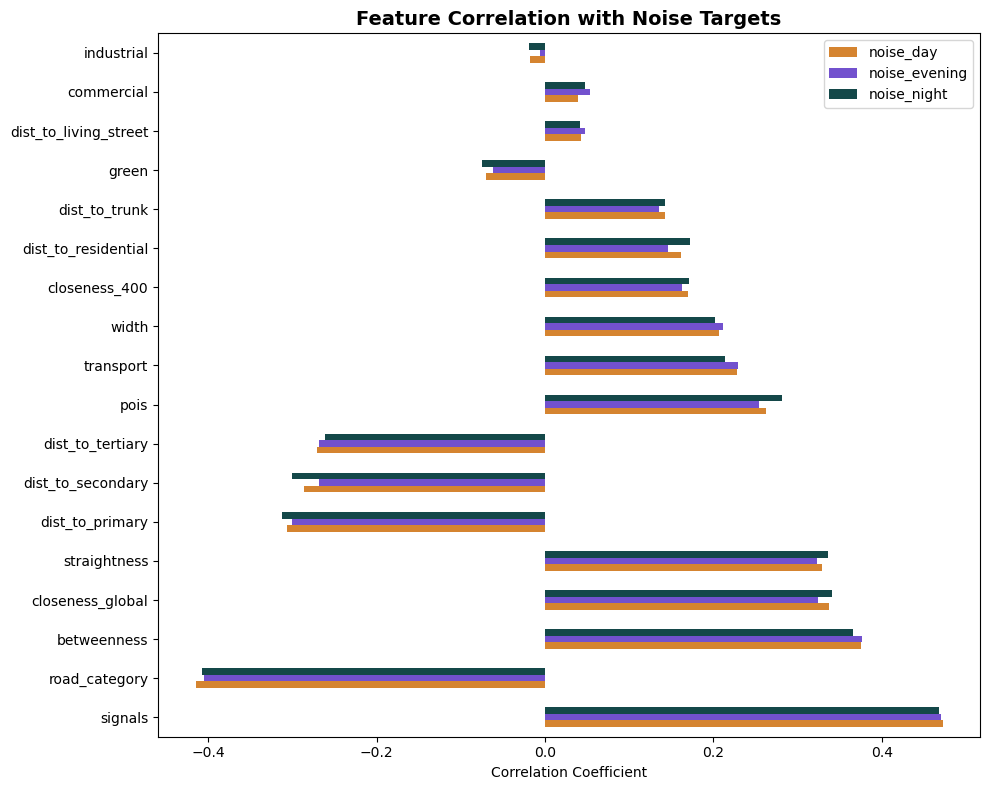

                       noise_day  noise_evening  noise_night
signals                 0.472368       0.470706     0.468409
betweenness             0.374827       0.376778     0.366425
closeness_global        0.337057       0.324295     0.340865
straightness            0.328797       0.322796     0.336034
pois                    0.262054       0.254061     0.281312
transport               0.227780       0.228970     0.213595
width                   0.206131       0.211747     0.201789
closeness_400           0.169730       0.163201     0.171160
dist_to_residential     0.161962       0.146246     0.171936
dist_to_trunk           0.143139       0.135570     0.142345
dist_to_living_street   0.043161       0.047487     0.041767
commercial              0.039346       0.053566     0.047537
industrial             -0.018350      -0.006078    -0.018597
green                  -0.070161      -0.061843    -0.074543
dist_to_tertiary       -0.270917      -0.268611    -0.261292
dist_to_secondary      -

In [21]:
# Extract correlations with noise predictions
dataset_filtered = dataset.drop(columns=['road_id']) #dropping non-relevant columns
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax,color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

In [22]:
dataset_pairs = dataset.drop(columns=['road_id', 'noise_evening', 'noise_night']) 

# Sample randomly
sample = dataset_pairs.sample(n=1000, random_state=42).copy()

# Get unique noise_day values sorted and convert to ordered categorical
sorted_noise_values = sorted(sample['noise_day'].unique())
sample['noise_day'] = pd.Categorical(sample['noise_day'], categories=sorted_noise_values, ordered=True)



In [23]:
# other plots can be
# histograms
# paralel coordinates plot
# boxplots/violonplots for distributions

In [24]:
print("Noise Day values:")
print(dataset['noise_day'].unique())
print("\nUnique values count:", dataset['noise_day'].nunique())


Noise Day values:
[2 1 3 4 0]

Unique values count: 5
